Trainig an ML model

- Data Transformation

In [2]:
"""
Encodes each miRNA-target site pair in a TSV with reverse-complement miRNA k-mer count features from the gene sequence, for k = 2 to 12.

Usage:
    python encode.py --input_dataset <INPUT_TSV> --output_encoded_dataset <OUTPUT_TSV>

Arguments:
    --input_dataset           Path to input dataset (TSV)
    --output_encoded_dataset  Output path for encoded dataset with k-mer features (TSV)
"""

from Bio.Seq import Seq
import pandas as pd
import os

MIRNA_LENGTH = 20
K_MIN = 2
K_MAX = 12

def reverse_complement(seq):
    """Return the reverse complement of a nucleotide sequence using Biopython."""
    seq_obj = Seq(seq)
    return str(seq_obj.reverse_complement())

def truncate_or_pad(seq, desired_length=MIRNA_LENGTH):
    """
    Truncate the sequence if it's longer than the desired length,
    or pad it with 'N' if it's shorter.
    """
    return seq[:desired_length] if len(seq) > desired_length else seq.ljust(desired_length, 'N')

def count_kmers(miRNA, gene, k):
    """
    For a given k, compute a dictionary of counts for each k-mer's reverse complement
    in the gene. The keys are formatted as 'pos<position>_k<k>'.
    """
    counts = {}
    for i in range(len(miRNA) - k + 1):
        kmer = miRNA[i:i+k]
        rev = reverse_complement(kmer)
        counts[f'pos{i+1}_k{k}'] = gene.count(rev)
    return counts

def process_dataset(dataset, sep=',', chunk_size=10000):
    """
    Reads a TSV file in chunks and extracts features based on the count of reverse complement k-mers 
    from the miRNA present in the corresponding gene sequence.
    Returns a DataFrame with the original 'noncodingRNA', 'gene', 'label' columns 
    followed by the k-mer count features.
    """
    rows = []
    for chunk in pd.read_csv(dataset, sep=sep, chunksize=chunk_size):
        for _, row in chunk.iterrows():
            # Prepare the feature dictionary with the original columns.
            features = {
                'noncodingRNA': row['noncodingRNA'],
                'gene': row['gene'],
                'label': row['label']
            }
            miRNA = truncate_or_pad(str(row['noncodingRNA']))
            gene = str(row['gene']).upper()
            # Compute k-mer counts for each k between K_MIN and K_MAX.
            for k in range(K_MIN, K_MAX + 1):
                kmers = count_kmers(miRNA, gene, k)
                features.update(kmers)
            rows.append(features)
    df = pd.DataFrame(rows)
    return df



In [ ]:
df_encoded = process_dataset("AGO2_CLASH_Hejret2023.csv", sep=',')
df_encoded.to_csv("AGO2_CLASH_Hejret2023_encoded.tsv", sep='\t', index=False)
df_encoded.head()

,noncodingRNA,gene,label,pos1_k2,pos2_k2,pos3_k2,pos4_k2,pos5_k2,pos6_k2,pos7_k2,...,pos10_k11,pos1_k12,pos2_k12,pos3_k12,pos4_k12,pos5_k12,pos6_k12,pos7_k12,pos8_k12,pos9_k12
0,AAAGCAAATGTTGGGTGAACGGC,GGAGTCTGGAGTCAAACCCAGAGCAGCTGCAGGCCATGAGGCACAT...,0,2,2,2,5,4,2,2,...,0,0,0,0,0,0,0,0,0,0
1,AATAGCTCAGAATGTCAGTTCTG,CAGCTGTGTACAGCGCCATCTCTCTGCCTTCTGTTGCCCCTCACTC...,0,2,1,1,8,5,2,0,...,0,0,0,0,0,0,0,0,0,0
2,AGAATTCTCTTATCCAACATCAACA,GCCTCATGCGCTCACGGGTTCGGGGGGCCGATGCTGCCCAAGCCAA...,0,3,4,1,2,2,1,2,...,0,0,0,0,0,0,0,0,0,0
3,GCTAAGGAAGTCCTGTGCTCAG,AAGAAAATGGTTCAAGGGCATGGGGGTTAGAGAATGTTTCTTTTAC...,0,1,4,3,5,2,1,2,...,0,0,0,0,0,0,0,0,0,0
4,TGAAGCGCCTGTGCTCTGCCGAGA,CCACCTGCAACCCCAATCTCAATCCGGAGGCCAGTAGCACCAGGAT...,0,7,3,0,2,3,1,3,...,0,0,0,0,0,0,0,0,0,0


Average Precision score for 6-mer total count: 0.7810
Average Precision score for 7-mer total count: 0.6971
Average Precision score for 8-mer total count: 0.6076


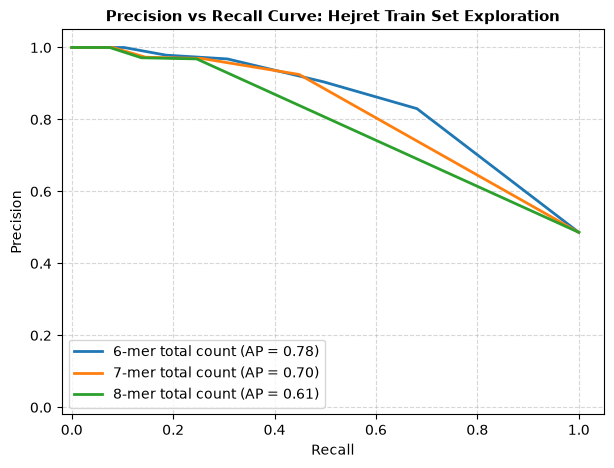

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

kmers_data = []
lengths = [6, 7, 8]
for k in lengths:
    k_columns = [col for col in df_encoded.columns if f'_k{k}' in col]
    
    if k_columns:
        scores = df_encoded[k_columns].sum(axis=1)
        
        precision, recall, _ = precision_recall_curve(df_encoded['label'], scores)
        ap = average_precision_score(df_encoded['label'], scores)
        
        kmers_data.append({
            'model': f'{k}-mer total count',
            'precision': precision,
            'recall': recall,
            'ap': ap
        })

plt.figure(figsize=(7, 5))
for item in kmers_data:
    plt.plot(item['recall'], item['precision'], label=f"{item['model']} (AP = {item['ap']:.2f})", linewidth=2)
    print(f'Average Precision score for {item["model"]}: {item["ap"]:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Curve: Hejret Train Set Exploration", fontsize=11, fontweight='bold')
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left")
plt.show()
